In [31]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg import maps
from simpeg.potential_fields import magnetics

write_output = False

import torch

### **Crear modelo de SimPEG**



In [ ]:
# 1) Malla

dx = 18042.46/50
ncx = 50
dy = 20729.81/50
ncy = 50
dz = 8500/50
ncz = 50


hx = [(dx, ncx)]
hy = [(dy, ncy)]
hz = [(dz, ncz)]
mesh = TensorMesh([hx, hy, hz], x0=[4609667.74, 1800295.19, -3500])

In [33]:
mesh

TensorMesh: 125,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     50  4,609,667.74  4,627,710.20    360.85    360.85    1.00
   y     50  1,800,295.19  1,821,025.00    414.60    414.60    1.00
   z     50     -3,500.00      5,000.00    170.00    170.00    1.00

In [ ]:
# 2) Modelo y receptores

model_npz = np.load("../../../../models/modelC/mag_modelC.npz")

model = model_npz["Mag_model"]
cell_centers = model_npz["cell_centers"]    # (nx, ny, nz), bool
dx = model_npz["dx"]                      # (nx, ny, nz)
dy = model_npz["dy"]                      # (nx, ny, nz)
dz = model_npz["dz"]                      # (nx, ny, nz)

receiver_location = np.load("receivers_modelC.npy")


In [35]:
cell_centers.shape

(125000, 3)

In [36]:
np.unique(model)

array([-0.0009539, -0.0008283, -0.0005769,  0.       ,  0.0003257,
        0.0051416,        nan])

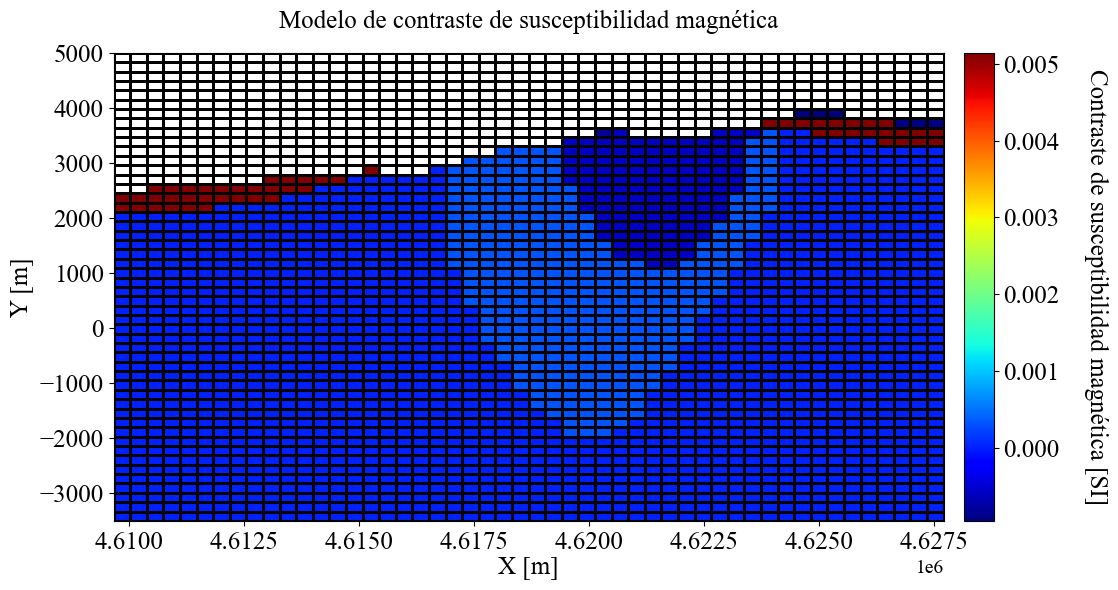

In [37]:
# 3) Visualización del modelo de contraste de susceptibilidad magnética

fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_axes([0.1, 0.12, 0.83, 0.78])
mpl.rcParams["font.family"] = "Times New Roman"

m = model   
y_slice_coord = mesh.x0[1] + mesh.h[1].sum() / 2

mesh.plot_slice(
    m,
    normal="Y",
    ax=ax1,
    #slice_loc=2056000,
    grid=True,
    clim=(np.nanmin(m), np.nanmax(m)),
    pcolor_opts={"cmap": "jet"},
)
ax1.set_title(f"Modelo de contraste de susceptibilidad magnética", size=18, pad=18)
ax1.set_xlabel("X [m]", size=18, labelpad=1)
ax1.set_ylabel("Y [m]", size=18)
ax1.tick_params(axis="both", which="major", labelsize=18)
mpl.rcParams["font.family"] = "Times New Roman"

# Offset text (ej: 1e6) en ambos ejes
ax1.xaxis.get_offset_text().set_size(14)
ax1.yaxis.get_offset_text().set_size(14)
# Colorbar
ax2 = fig.add_axes([0.95, 0.12, 0.03, 0.78])
norm = mpl.colors.Normalize(vmin=np.nanmin(m), vmax=np.nanmax(m))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.jet
)

cbar.set_label(
    r"Contraste de susceptibilidad magnética [SI]",
    rotation=270,
    labelpad=35,
    fontsize=18
)
cbar.ax.tick_params(labelsize=14) 
cbar.ax.yaxis.get_offset_text().set_size(14)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

tick_fs = 18      
label_fs = 22     
title_fs = 22     

plt.show()

out_png = "ModelC_SimPEG.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

In [38]:
print(y_slice_coord)

1810660.095


In [ ]:
# 4) Celdas activas

ind_active = ~np.isnan(model)        
n_active = ind_active.sum()

In [40]:
ind_active

array([ True,  True,  True, ..., False, False, False], shape=(125000,))

In [41]:
n_active

np.int64(95470)

In [ ]:
# 5) Mapeo del modelo

model_map = maps.IdentityMap(nP=n_active)

In [ ]:
# 6) Survey magnético

components = ["tmi"]

receiver_list = magnetics.receivers.Point(receiver_location, components=components)
receiver_list = [receiver_list]

inclination = 24
declination = -5
strength = 29773.7

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=strength,
    inclination=inclination,
    declination=declination,
)

survey = magnetics.survey.Survey(source_field)


In [ ]:
# 7) Simulación forward

simulation = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    model_type="scalar",   
    chiMap=model_map,
    active_cells=ind_active,
    store_sensitivities="forward_only",
)

In [45]:
# 8) Modelo activo

model_active = model[~np.isnan(model)]
np.unique(model_active)

array([-0.0009539, -0.0008283, -0.0005769,  0.       ,  0.0003257,
        0.0051416])

In [46]:
model_active.shape

(95470,)

In [47]:
dpred = simulation.dpred(model_active)

In [48]:
model_active.shape

(95470,)

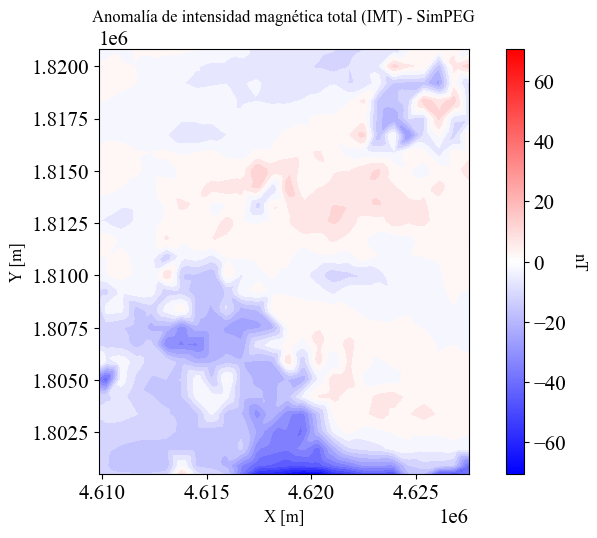

In [49]:
# 9) Plot Anomalía de intensidad magnética total (IMT) calculada con SimPEG

fig = plt.figure(figsize=(6, 5))
v_max = np.max(np.abs(dpred))

ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.85])
plot2Ddata(
    receiver_list[0].locations,
    dpred,
    ax=ax1,
    ncontour=30,
    clim=(-v_max, v_max),
    contourOpts={"cmap": "bwr"},
)
ax1.set_title("Anomalía de intensidad magnética total (IMT) - SimPEG")
ax1.set_xlabel("X [m]", size=12)
ax1.set_ylabel("Y [m]", size=12)

ax2 = fig.add_axes([0.87, 0.1, 0.03, 0.85])
norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dpred)), vmax=np.max(np.abs(dpred)))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("nT", rotation=270, labelpad=15, size=12)

plt.show()

out_png = "Modeling_modelC_SimPEG.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")

In [ ]:
# 10) Exportación de la respuesta calculada

obs_xyz_np = np.asarray(receiver_location, float)
resp_np    = np.asarray(dpred, float).reshape(-1)

if obs_xyz_np.ndim != 2 or obs_xyz_np.shape[1] != 3:
    raise ValueError(f"obs_xyz debe ser (nObs,3). Llegó: {obs_xyz_np.shape}")
if resp_np.size != obs_xyz_np.shape[0]:
    raise ValueError(f"Respuesta y obs no coinciden: {resp_np.size} vs {obs_xyz_np.shape[0]}")

out = np.column_stack([obs_xyz_np, resp_np])  # (nObs,4)

np.save("response_modelC_SimPEG.npy", out)

In [ ]:
# 11) Carga de respuestas para comparación

simpeg = np.load("response_modelC_SimPEG.npy")
op = np.load("../Mag_modelC/response_modelC.npy")

In [52]:
re = dpred - op[:,-1]
np.max(re)

np.float64(1.8494272779889798e-10)

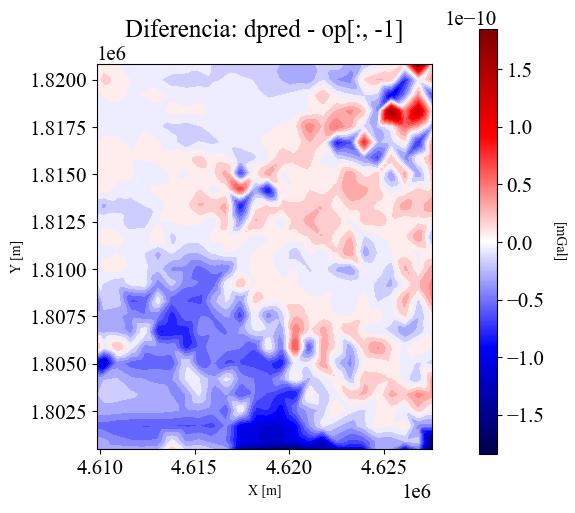

In [53]:
# 12) Mapa de diferencia entre SimPEG y el operador

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


difference = dpred - op[:, -1]

locs = receiver_list[0].locations 

vmin = np.nanmin(difference)
vmax = np.nanmax(difference)


fig, ax = plt.subplots(figsize=(6, 5))

plot2Ddata(locs, difference, ax=ax, ncontour=30, clim=(vmin, vmax), contourOpts={"cmap": "seismic"})

ax.set_title("Diferencia: dpred - op[:, -1]", fontsize=18)
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = mpl.colorbar.ColorbarBase(ax=fig.add_axes([0.87, 0.1, 0.03, 0.85]), norm=norm, orientation="vertical", cmap=mpl.cm.seismic)
cbar.set_label("[mGal]", rotation=270, labelpad=15)

plt.show()


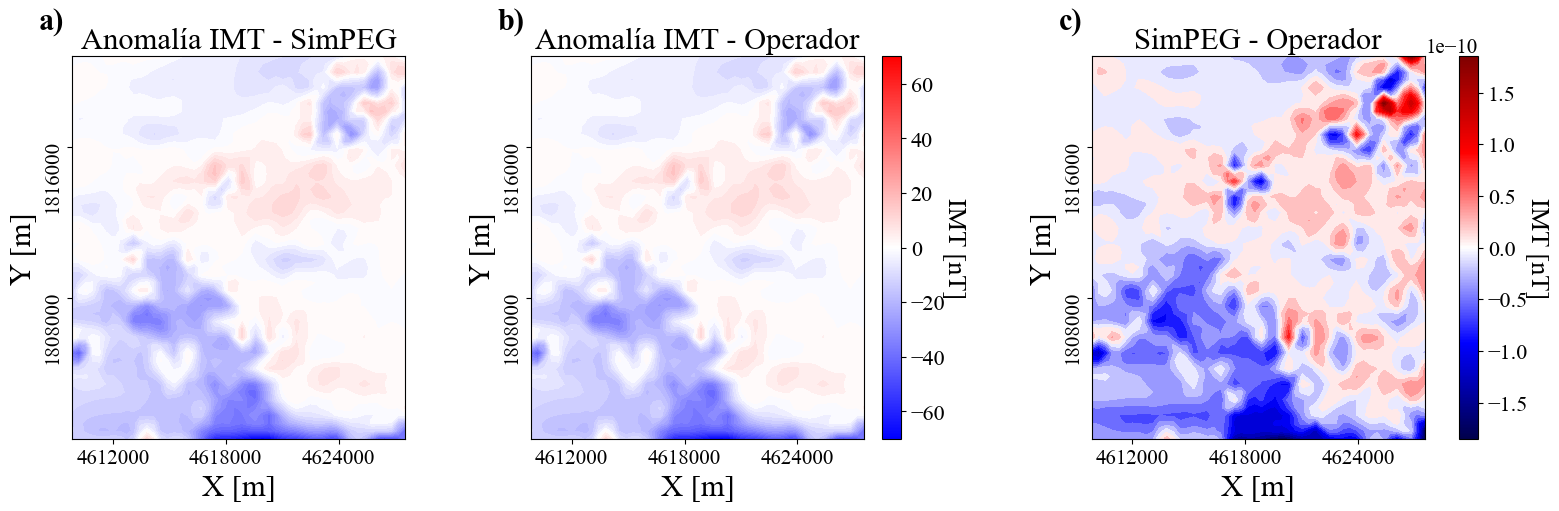

In [68]:
# 13) Comparación SimPEG vs operador

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

mpl.rcParams["font.family"] = "Times New Roman"

op = np.asarray(op)
simpeg = np.asarray(simpeg)

xy_op = op[:, :2]
val_op = op[:, 2].ravel()

xy_sp = simpeg[:, :2]
val_sp = simpeg[:, 3].ravel()

if val_op.size != val_sp.size:
    raise ValueError(f"Size mismatch: operator={val_op.size} vs simpeg={val_sp.size}")

residual = val_sp - val_op

nx, ny = 50, 50
xmin = min(xy_op[:,0].min(), xy_sp[:,0].min())
xmax = max(xy_op[:,0].max(), xy_sp[:,0].max())
ymin = min(xy_op[:,1].min(), xy_sp[:,1].min())
ymax = max(xy_op[:,1].max(), xy_sp[:,1].max())

xlin = np.linspace(xmin, xmax, nx)
ylin = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(xlin, ylin)

method = "cubic"

Z_sp = griddata(xy_sp, val_sp, (X, Y), method=method)
Z_op = griddata(xy_op, val_op, (X, Y), method=method)
Z_rs = Z_sp - Z_op  

vmin, vmax = -70, 70            
rmax = np.nanmax(np.abs(Z_rs))
rmin, rmax = -rmax, rmax          

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

im0 = axes[0].contourf(X, Y, Z_sp, levels=30, cmap="bwr", vmin=vmin, vmax=vmax)
axes[0].set_title("Anomalía IMT - SimPEG", fontsize=22)

im1 = axes[1].contourf(X, Y, Z_op, levels=30, cmap="bwr", vmin=vmin, vmax=vmax)
axes[1].set_title("Anomalía IMT - Operador", fontsize=22)

im2 = axes[2].contourf(X, Y, Z_rs, levels=30, cmap="seismic", vmin=rmin, vmax=rmax)
axes[2].set_title("SimPEG - Operador", fontsize=22)

for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X [m]", fontsize=14)
    ax.set_ylabel("Y [m]", fontsize=14)
    ax.tick_params(axis="x", labelrotation=0, labelsize=14)
    ax.tick_params(axis="y", labelrotation=90, labelsize=14)
    ax.ticklabel_format(style="plain", useOffset=False, axis="both") 

import matplotlib.ticker as mticker

for ax in axes:
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
    ax.tick_params(axis="both", labelsize=13) 

for ax in axes:
    ax.ticklabel_format(style="plain", useOffset=False, axis="both")


norm12 = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm12 = mpl.cm.ScalarMappable(norm=norm12, cmap=mpl.cm.bwr)
sm12.set_array([])

cbar12 = fig.colorbar(
    sm12,
    ax=axes[:2],
    fraction=0.046,
    shrink=1,
    pad=0.02
)
cbar12.set_label("IMT [nT]", rotation=270, labelpad=15, size=19)
cbar12.ax.tick_params(labelsize=16)

norm3 = mpl.colors.Normalize(vmin=rmin, vmax=rmax)
sm3 = mpl.cm.ScalarMappable(norm=norm3, cmap=mpl.cm.seismic)
sm3.set_array([])

cbar3 = fig.colorbar(
    sm3,
    ax=axes[2],
    fraction=0.046,   
    shrink=1,     
    pad=0.002    
)
cbar3.set_label("IMT [nT]", rotation=270, labelpad=15, size=19)
cbar3.ax.tick_params(labelsize=16)


mpl.rcParams["xtick.labelsize"] = 15
mpl.rcParams["ytick.labelsize"] = 15

tick_fs = 15     
label_fs = 22     
title_fs = 22     

for ax in axes:

    ax.tick_params(axis="x", which="major", labelsize=tick_fs, labelrotation=0)  
    ax.tick_params(axis="y", which="major", labelsize=tick_fs, labelrotation=90) 
    ax.set_xlabel("X [m]", fontsize=label_fs)
    ax.set_ylabel("Y [m]", fontsize=label_fs)
    

labels = ["a)", "b)", "c)"]

for ax, lab in zip(axes, labels):
    ax.text(
       -0.10,1.05, lab,                
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=22, fontweight="bold",
        clip_on=False                  
    )

ax1.xaxis.get_offset_text().set_size(18)
ax1.yaxis.get_offset_text().set_size(18)
plt.show()

In [ ]:
# 14) Datos para métricas

val_sp - val_op

y_true=val_sp
y_pred=val_op
val_sp-= np.min(val_sp)
val_sp/= np.max(val_sp) 

val_op-= np.min(val_op)
val_op/= np.max(val_op) 

In [69]:
# Error Medio Absoluto (MAE)

mae = np.mean(np.abs(y_true - y_pred))
print(mae)

1.035120224659931e-12


In [70]:
# Raíz del Error Cuadrático Medio (RMSE)

rmse = np.sqrt(np.mean((y_true - y_pred)**2))
print(rmse)

1.0855450291615427e-12


In [71]:
# Error Porcentual Medio Absoluto (MAPE)

eps = 1e-8
mape = 100 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))
print(mape)

1.3788980875391864e-10


In [72]:
#PSNR

mse = np.mean((y_true - y_pred)**2)
Imax = np.max(y_true)
psnr = 10 * np.log10(Imax**2 / mse)
print(psnr)

239.28704313998523


In [73]:
#SSIM

from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim_metric = StructuralSimilarityIndexMeasure(data_range=Imax - np.min(y_true))
y_true_COPY = torch.from_numpy(y_true.reshape(26, 26)).unsqueeze(0).unsqueeze(0)
y_pred_COPY = torch.from_numpy(y_pred.reshape(26, 26)).unsqueeze(0).unsqueeze(0)
print(y_true_COPY.shape)

print(ssim_metric(y_true_COPY, y_pred_COPY).item())


torch.Size([1, 1, 26, 26])
1.0
